In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from darts import TimeSeries
from darts.models import RNNModel
from darts.dataprocessing.transformers import Scaler
from darts.metrics import mape, rmse, mae
from darts.utils.timeseries_generation import datetime_attribute_timeseries

In [21]:
# ==================== 1. 数据加载和预处理 ====================
def load_and_prepare_data(file_path):
    """
    加载CSV文件并转换为Darts TimeSeries列表
    假设CSV包含列: trade_date, ts_code, open, high, low, close, volume, ...
    """
    print("正在加载数据...")
    df = pd.read_csv(file_path, parse_dates=['trade_date'])

    # 按股票代码分组
    stock_groups = df.groupby('ts_code')
    series_list = []

    for stock_code, group in stock_groups:
        # 按日期排序
        group = group.sort_values('trade_date').copy()

        # 选择特征列（只保留实际存在的列）
        all_candidates = ['close', 'open', 'high', 'low', 'pre_close', 'change', 'pct_chg', 'vol', 'amount', 'open_qfq', 'high_qfq', 'low_qfq', 'close_qfq', 'pre_close_qfq', 'open_hfq', 'high_hfq', 'low_hfq', 'close_hfq', 'pre_close_hfq', 'turnover_rate',
                         'turnover_rate_f', 'volume_ratio', 'pe', 'pe_ttm', 'pb', 'ps', 'ps_ttm', 'dv_ratio', 'dv_ttm', 'total_share', 'float_share', 'free_share', 'total_mv', 'circ_mv', 'adj_factor', 'ema_bfq_250', 'ema_qfq_250', 'ema_hfq_250']
        value_cols = [c for c in all_candidates if c in group.columns]
        if not value_cols:
            continue

        # 清洗 NaN/Inf，避免标准化和评估时出现 nan
        sub = group[value_cols]
        sub = sub.replace([np.inf, -np.inf], np.nan)
        sub = sub.ffill().bfill().fillna(0)  # 前向/后向填充，剩余填 0
        group[value_cols] = sub

        # 转换为Darts TimeSeries
        series = TimeSeries.from_dataframe(
            group,
            time_col='trade_date',
            value_cols=value_cols,
            fill_missing_dates=True,
            freq='D'
        )

        # 只保留有足够数据的股票（比如至少500个交易日）
        if len(series) >= 500:
            series_list.append(series)
            if len(series_list) <= 5:  # 只打印前5只的信息
                print(f"股票 {stock_code}: {len(series)} 个交易日")

    print(f"成功加载 {len(series_list)} 只股票的数据")
    return series_list

In [22]:
series_list = load_and_prepare_data('../data/stock_000001.csv')

正在加载数据...
股票 000001.SZ: 4014 个交易日
成功加载 1 只股票的数据


In [23]:
# ==================== 2. 划分函数 ====================
def split_by_time(series_list, train_end='2019-12-31', val_end='2023-12-31'):
    """
    严格按时间划分训练/验证/测试集
    使用Darts内置的切片方法
    """
    train_series = []
    val_series = []
    test_series = []

    # 转换日期
    train_end_ts = pd.Timestamp(train_end)
    val_end_ts = pd.Timestamp(val_end)

    # 记录每只股票的划分情况
    stock_stats = []

    for i, series in enumerate(series_list):
        try:
            # 方法1: 使用split_before和split_after（推荐）
            # 先切出训练集
            train_part, rest = series.split_before(train_end_ts)

            # 从剩余部分切出验证集和测试集
            val_part, test_part = rest.split_before(val_end_ts)

            # 添加到对应的列表
            if len(train_part) > 0:
                train_series.append(train_part)
            if len(val_part) > 0:
                val_series.append(val_part)
            if len(test_part) > 0:
                test_series.append(test_part)

            # 记录前3只股票的详细信息
            if i < 3:
                stock_stats.append({
                    'index': i,
                    '总天数': len(series),
                    '训练集天数': len(train_part) if len(train_part) > 0 else 0,
                    '验证集天数': len(val_part) if len(val_part) > 0 else 0,
                    '测试集天数': len(test_part) if len(test_part) > 0 else 0,
                    '训练集范围': f"{train_part.start_time()} 到 {train_part.end_time()}" if len(train_part) > 0 else "无",
                    '验证集范围': f"{val_part.start_time()} 到 {val_part.end_time()}" if len(val_part) > 0 else "无",
                    '测试集范围': f"{test_part.start_time()} 到 {test_part.end_time()}" if len(test_part) > 0 else "无"
                })

        except Exception as e:
            print(f"处理股票 {i} 时出错: {e}")
            continue

    print(f"\n训练集: {len(train_series)} 只股票")
    print(f"验证集: {len(val_series)} 只股票")
    print(f"测试集: {len(test_series)} 只股票")

    # 打印前3只股票的详细划分信息
    if stock_stats:
        print("\n前3只股票划分详情:")
        for stat in stock_stats:
            print(f"\n股票 {stat['index']+1}:")
            print(f"  总天数: {stat['总天数']}")
            print(f"  训练集: {stat['训练集天数']}天 ({stat['训练集范围']})")
            print(f"  验证集: {stat['验证集天数']}天 ({stat['验证集范围']})")
            print(f"  测试集: {stat['测试集天数']}天 ({stat['测试集范围']})")

    return train_series, val_series, test_series

In [24]:
train_series, val_series, test_series = split_by_time(
    series_list, train_end='2019-12-31', val_end='2023-12-31')


训练集: 1 只股票
验证集: 1 只股票
测试集: 1 只股票

前3只股票划分详情:

股票 1:
  总天数: 4014
  训练集: 1821天 (2015-01-05 00:00:00 到 2019-12-30 00:00:00)
  验证集: 1461天 (2019-12-31 00:00:00 到 2023-12-30 00:00:00)
  测试集: 732天 (2023-12-31 00:00:00 到 2025-12-31 00:00:00)


In [25]:
# ==================== 3. 数据标准化 ====================
def normalize_series(train_series, val_series, test_series):
    """
    在训练集上拟合scaler，然后转换验证集和测试集
    避免数据泄露
    """
    # 对所有股票使用同一个scaler（保持尺度一致）
    scaler = Scaler()

    # 在训练集上拟合
    train_scaled = [scaler.fit_transform(series) for series in train_series]

    # 转换验证集和测试集
    val_scaled = [scaler.transform(series)
                  for series in val_series] if val_series else []
    test_scaled = [scaler.transform(series)
                   for series in test_series] if test_series else []

    print("数据标准化完成")
    return train_scaled, val_scaled, test_scaled, scaler

In [26]:
train_scaled, val_scaled, test_scaled, scaler = normalize_series(
    train_series, val_series, test_series)

数据标准化完成


In [27]:
# ==================== 4. 创建协变量（可选） ====================
def create_covariates(series_list):
    """
    创建时间特征作为未来协变量
    例如：月份、星期几、节假日等
    """
    covariate_list = []

    for series in series_list:
        # 获取时间索引
        time_idx = series.time_index

        # 创建月份特征（周期性编码）
        month_series = datetime_attribute_timeseries(
            time_idx,
            attribute='month',
            cyclic=True  # 循环编码，让12月和1月接近
        )

        # 创建星期特征
        day_series = datetime_attribute_timeseries(
            time_idx,
            attribute='dayofweek',
            cyclic=True
        )

        # 合并协变量
        covariates = month_series.stack(day_series)
        covariate_list.append(covariates)

    return covariate_list

In [28]:
# ==================== 5. 模型训练 ====================
def train_lstm_model(train_scaled, val_scaled, input_chunk_length=60):

    print("\n开始训练LSTM模型...")
    print(
        f"参数设置: input_chunk_length={input_chunk_length}, output_chunk_length=1")

    # 计算training_length
    training_length = input_chunk_length + 24

    # 创建LSTM模型 - 完全禁用日志
    model = RNNModel(
        model='LSTM',
        input_chunk_length=input_chunk_length,
        output_chunk_length=1,
        training_length=training_length,
        hidden_dim=128,
        n_rnn_layers=2,
        dropout=0.2,
        batch_size=64,
        n_epochs=10,
        optimizer_kwargs={'lr': 1e-3},
        random_state=42,
        force_reset=True,
        pl_trainer_kwargs={
            'accelerator': 'auto',
            'devices': 'auto',
            'enable_progress_bar': True,
            'enable_model_summary': True,
            'logger': False,
            'log_every_n_steps': 0,
            'gradient_clip_val': 1.0,  # 梯度裁剪，防止梯度爆炸导致 nan
        }
    )

    # 训练模型
    model.fit(
        series=train_scaled,
        val_series=val_scaled if val_scaled else None,
        verbose=True
    )

    print("模型训练完成")
    return model

In [29]:
train_scaled = train_scaled[:1]
model = train_lstm_model(train_scaled, val_scaled, input_chunk_length=60)

ignoring user defined `output_chunk_length`. RNNModel uses a fixed `output_chunk_length=1`.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name            | Type             | Params | Mode  | FLOPs
---------------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train | 0    
1 | train_criterion | MSELoss          | 0      | train | 0    
2 | val_criterion   | MSELoss          | 0      | train | 0    
3 | train_metrics   | MetricCollection | 0      | train | 0    
4 | val_metrics     | MetricCollection | 0      | train | 0    
5 | rnn             | LSTM             | 218 K  | train | 0    
6 | V               | Linear         


开始训练LSTM模型...
参数设置: input_chunk_length=60, output_chunk_length=1
                                                                            

d:\Python_Project\thesis\.venv\lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Epoch 9: 100%|██████████| 28/28 [00:01<00:00, 15.44it/s, train_loss=nan.0, val_loss=nan.0]

`Trainer.fit` stopped: `max_epochs=10` reached.


Epoch 9: 100%|██████████| 28/28 [00:01<00:00, 15.43it/s, train_loss=nan.0, val_loss=nan.0]
模型训练完成


In [30]:
# ==================== 6. 模型评估 ====================
def evaluate_model(model, test_scaled, scaler, n_predict=30):
    """
    在测试集上评估模型
    """
    print("\n开始评估模型...")

    all_mape = []
    all_rmse = []

    # 对每只测试股票进行预测
    for i, test_series in enumerate(test_scaled[:10]):  # 只测试前10只，避免太慢
        # 划分历史数据和待预测数据
        history = test_series[:-n_predict] if len(
            test_series) > n_predict else test_series[:-1]
        true_future = test_series[-n_predict:] if len(
            test_series) > n_predict else test_series[-1:]

        if len(history) < model.input_chunk_length:
            continue

        # 预测
        forecast = model.predict(
            n=len(true_future),
            series=history
        )

        # 反标准化回原始尺度
        forecast_original = scaler.inverse_transform(forecast)
        true_original = scaler.inverse_transform(true_future)

        # 计算指标：多分量时 MAPE 易因某分量为 0 而 nan，故对第一分量(如 close)单独算 MAPE
        rmse_val = rmse(true_original, forecast_original)
        mae_val = mae(true_original, forecast_original)
        try:
            t0 = true_original.univariate_component(0)
            f0 = forecast_original.univariate_component(0)
            mape_val = mape(t0, f0)
        except Exception:
            mape_val = np.nan
        if not np.isfinite(mape_val):
            mape_val = np.nan
        all_mape.append(mape_val)
        all_rmse.append(rmse_val)

        if i < 3:
            print(f"股票 {i+1}: MAPE={mape_val:.2f}%, RMSE={rmse_val:.2f}, MAE={mae_val:.2f}")

        # 绘制预测结果（可选）
        if i == 0:
            plt.figure(figsize=(12, 6))
            true_original.plot(label='Actual', lw=2)
            forecast_original.plot(label='Forecast', lw=2)
            plt.title(f'Stock {i+1} Price Prediction')
            plt.legend()
            plt.grid(True)
            plt.savefig('prediction_example.png')
            plt.show()

    # 总体结果（用 nanmean 避免个别 nan 拖垮整体）
    print(f"\n总体结果（基于{len(all_mape)}只股票）:")
    print(f"平均MAPE: {np.nanmean(all_mape):.2f}%")
    print(f"平均RMSE: {np.nanmean(all_rmse):.2f}")

    return all_mape, all_rmse


# ==================== 7. 回测（可选） ====================
def backtest_model(model, train_scaled, test_scaled, scaler, horizon=30):
    """
    对模型进行回测，模拟真实交易场景
    """
    print("\n开始回测...")

    # 合并训练集和测试集（但按时间顺序）
    full_series = train_scaled + test_scaled

    backtest_results = []

    for series in full_series[:5]:  # 只测试5只
        if len(series) < model.input_chunk_length + horizon:
            continue

        # 历史回测
        backtest = model.historical_forecasts(
            series,
            start=0.8,  # 从80%的时间点开始回测
            forecast_horizon=horizon,
            stride=5,   # 每5天滑动一次
            retrain=False,  # 不重新训练（节省时间）
            verbose=False
        )

        # 计算误差
        error = mape(series, backtest)
        backtest_results.append(error)

        # 绘制回测结果（选第一只）
        if len(backtest_results) == 1:
            plt.figure(figsize=(12, 6))
            series[-200:].plot(label='Actual')
            backtest[-200:].plot(label='Backtest')
            plt.title('Backtest Example')
            plt.legend()
            plt.grid(True)
            plt.savefig('backtest_example.png')
            plt.show()

    print(f"回测平均MAPE: {np.mean(backtest_results):.2f}%")
    return backtest_results


开始评估模型...


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 79.24it/s]

d:\Python_Project\thesis\.venv\lib\site-packages\darts\metrics\metrics.py:798: RuntimeWarning: Mean of empty slice
  return np.nanmean(
d:\Python_Project\thesis\.venv\lib\site-packages\darts\metrics\utils.py:409: RuntimeWarning: Mean of empty slice
  vals = component_reduction(vals, axis=COMP_AX)
d:\Python_Project\thesis\.venv\lib\site-packages\darts\metrics\metrics.py:385: RuntimeWarning: Mean of empty slice
  return np.nanmean(
d:\Python_Project\thesis\.venv\lib\site-packages\darts\metrics\metrics.py:1616: RuntimeWarning: Mean of empty slice
  return np.nanmean(
Number of series components (38) is larger than the maximum number of components to plot (10). Plotting only the first `10` components. You can adjust the number of components to plot using `max_nr_components`.



股票 1: MAPE=nan%, RMSE=nan, MAE=nan


Number of series components (38) is larger than the maximum number of components to plot (10). Plotting only the first `10` components. You can adjust the number of components to plot using `max_nr_components`.


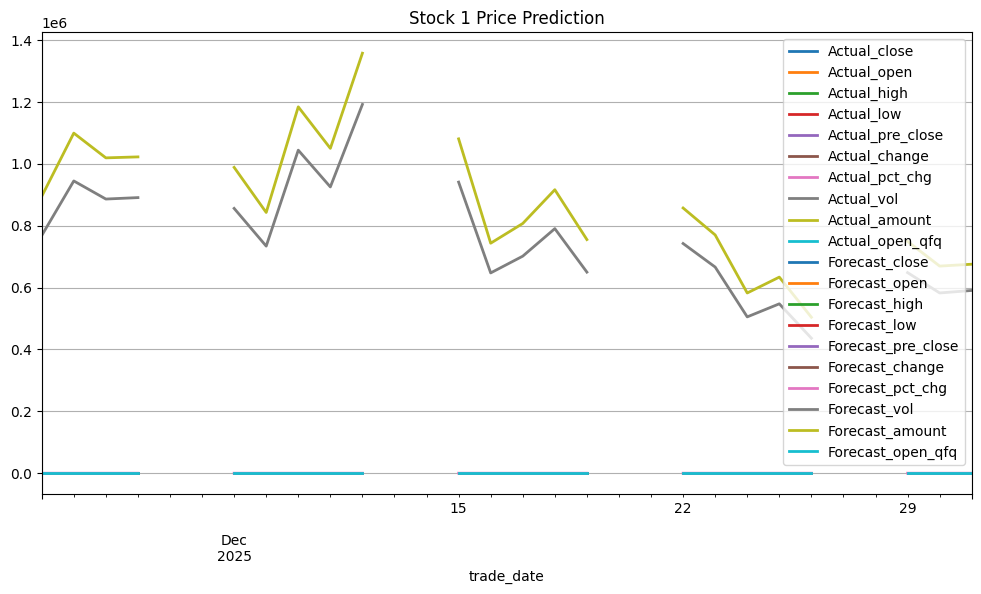


总体结果（基于1只股票）:
平均MAPE: nan%
平均RMSE: nan


C:\Users\35186\AppData\Local\Temp\ipykernel_28188\483156118.py:62: RuntimeWarning: Mean of empty slice
  print(f"平均MAPE: {np.nanmean(all_mape):.2f}%")
C:\Users\35186\AppData\Local\Temp\ipykernel_28188\483156118.py:63: RuntimeWarning: Mean of empty slice
  print(f"平均RMSE: {np.nanmean(all_rmse):.2f}")


In [31]:
all_mape, all_rmse = evaluate_model(model, test_scaled, scaler, n_predict=30)

ignoring user defined `output_chunk_length`. RNNModel uses a fixed `output_chunk_length=1`.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name            | Type             | Params | Mode  | FLOPs
---------------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train | 0    
1 | train_criterion | MSELoss          | 0      | train | 0    
2 | val_criterion   | MSELoss          | 0      | train | 0    
3 | train_metrics   | MetricCollection | 0      | train | 0    
4 | val_metrics     | MetricCollection | 0      | train | 0    
5 | rnn             | LSTM             | 218 K  | train | 0    
6 | V               | Linear         

正在加载数据...
股票 000001.SZ: 4014 个交易日
成功加载 1 只股票的数据

训练集: 1 只股票
验证集: 1 只股票
测试集: 1 只股票

前3只股票划分详情:

股票 1:
  总天数: 4014
  训练集: 1821天 (2015-01-05 00:00:00 到 2019-12-30 00:00:00)
  验证集: 1461天 (2019-12-31 00:00:00 到 2023-12-30 00:00:00)
  测试集: 732天 (2023-12-31 00:00:00 到 2025-12-31 00:00:00)
数据标准化完成

开始训练LSTM模型...
参数设置: input_chunk_length=60, output_chunk_length=1
                                                                            

d:\Python_Project\thesis\.venv\lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Epoch 9: 100%|██████████| 28/28 [00:01<00:00, 15.53it/s, train_loss=nan.0, val_loss=nan.0]

`Trainer.fit` stopped: `max_epochs=10` reached.


Epoch 9: 100%|██████████| 28/28 [00:01<00:00, 15.51it/s, train_loss=nan.0, val_loss=nan.0]
模型训练完成
模型已保存为 lstm_stock_model.pth

开始评估模型...


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 67.85it/s]

d:\Python_Project\thesis\.venv\lib\site-packages\darts\metrics\metrics.py:798: RuntimeWarning: Mean of empty slice
  return np.nanmean(
d:\Python_Project\thesis\.venv\lib\site-packages\darts\metrics\utils.py:409: RuntimeWarning: Mean of empty slice
  vals = component_reduction(vals, axis=COMP_AX)
d:\Python_Project\thesis\.venv\lib\site-packages\darts\metrics\metrics.py:385: RuntimeWarning: Mean of empty slice
  return np.nanmean(
d:\Python_Project\thesis\.venv\lib\site-packages\darts\metrics\metrics.py:1616: RuntimeWarning: Mean of empty slice
  return np.nanmean(
Number of series components (38) is larger than the maximum number of components to plot (10). Plotting only the first `10` components. You can adjust the number of components to plot using `max_nr_components`.
Number of series components (38) is larger than the maximum number of components to plot (10). Plotting only the first `10` components. You can adjust the number of components to plot using `max_nr_components`.



股票 1: MAPE=nan%, RMSE=nan, MAE=nan


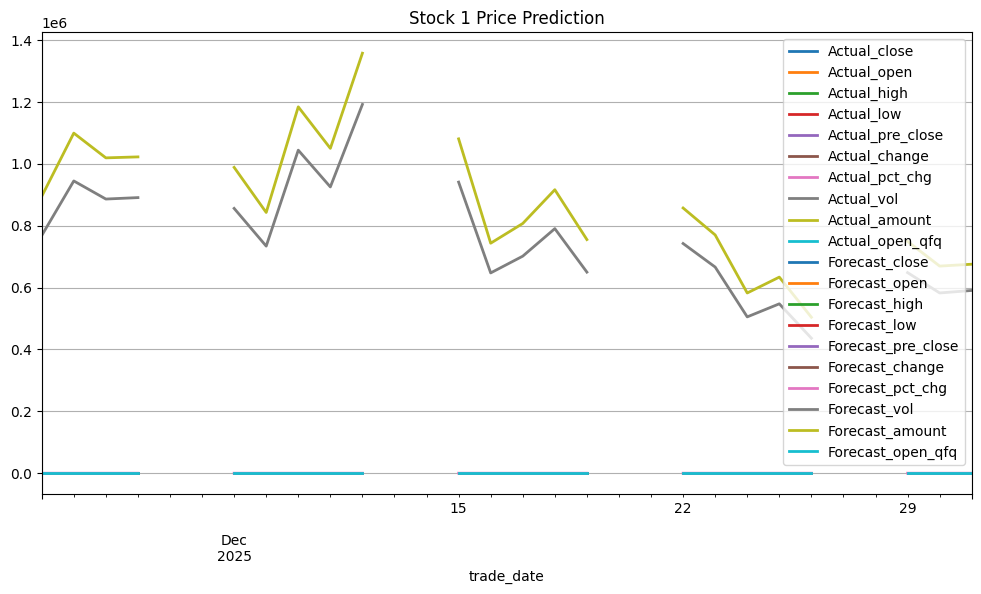


总体结果（基于1只股票）:
平均MAPE: nan%
平均RMSE: nan

全部完成！


C:\Users\35186\AppData\Local\Temp\ipykernel_28188\483156118.py:62: RuntimeWarning: Mean of empty slice
  print(f"平均MAPE: {np.nanmean(all_mape):.2f}%")
C:\Users\35186\AppData\Local\Temp\ipykernel_28188\483156118.py:63: RuntimeWarning: Mean of empty slice
  print(f"平均RMSE: {np.nanmean(all_rmse):.2f}")


In [ ]:
# 配置参数
CSV_PATH = '../data/stock_000001.csv'  # 请修改为你的文件路径
TRAIN_END = '2019-12-31'
VAL_END = '2023-12-31'
INPUT_LENGTH = 60  # 用60天预测下一天
OUTPUT_LENGTH = 1  # 预测1天

# 1. 加载数据
series_list = load_and_prepare_data(CSV_PATH)

# 2. 划分数据集
train_raw, val_raw, test_raw = split_by_time(
    series_list,
    train_end=TRAIN_END,
    val_end=VAL_END
)

# 3. 标准化
train_scaled, val_scaled, test_scaled, scaler = normalize_series(
    train_raw, val_raw, test_raw
)

# 4. 训练模型（使用修复后的函数）
model = train_lstm_model(
    train_scaled,
    val_scaled,
    input_chunk_length=INPUT_LENGTH
)

# 5. 保存模型
model.save('../models/lstm_stock_model.pth')
print("模型已保存为 lstm_stock_model.pth")

# 6. 评估模型
if test_scaled:
    evaluate_model(model, test_scaled, scaler, n_predict=30)

print("\n全部完成！")